# Parkinson's Tremor Detection

In [109]:
import pandas as pd
#import pandas_profiling, bamboolib
import numpy as np
from numpy import random
import scipy as sp
import matplotlib.pyplot as plt
#import seaborn as sns
#color = sns.color_palette()
import sklearn as skl
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier as RFC, GradientBoostingClassifier as GBC, AdaBoostClassifier as AdaBoost
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler, MinMaxScaler
from sklearn.model_selection import GridSearchCV, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC
from sklearn.svm import libsvm
from sklearn.metrics import accuracy_score, confusion_matrix
from scipy.stats import kurtosis, skew
import xgboost as XGB

from datetime import datetime
from datetime import timedelta
import math
#import random
from tensorflow import set_random_seed
import glob # for finding pathnames matching a specified pattern
import os
import gc # garbage collection, release memory when deleting variables
import re

#from scipy import stats
#from scipy.stats import norm, skew #for some statistics

import copy # use df_copy = copy.deepcopy(df) to copy a dataframe (e.g. called "df"), or use: df_copy = df.iloc[0:,0:], 
#but don't use df_copy = df (this is a "fake" copy by reference not by value, so changing value in df_copy will change df as well)

#pd.set_option("display.max_rows", None) # show all rows with scrollbar, don't use if there are many rows.
pd.set_option("display.max_rows", 1000) # show all rows with scrollbar, don't use if there are many rows.
pd.set_option("display.max_columns", None)
from IPython.core.interactiveshell import InteractiveShell
#InteractiveShell.ast_node_interactivity = "all"
%autosave 180

Autosaving every 180 seconds


In [110]:
def moving_average(f, npoints):
    # n-Point moving average, this window covers the point and its two sides of equal length.
    # The number of N points in moving average must be an odd number.
    f = np.array(f)
    Nsamples = len(f)
    f_ma = copy.deepcopy(f)
    if Nsamples == 0:
        return f_ma
    if npoints <= 0:
        return f_ma
    if npoints % 2 == 0:
        npoints = npoints + 1
    half_length = int((npoints-1)/2)

    for i in range(len(f)):
        if i < half_length and i < Nsamples/2:
            f_ma[i] = sum(f[:(2*i+1)])/(2*i+1)
        elif i < Nsamples - (npoints-1)/2:
            f_ma[i] = sum(f[(i-half_length):(i+half_length+1)])/npoints
        else:
            f_ma[i] = sum(f[(2*i+1-Nsamples):])/(2*Nsamples-2*i-1)

    return f_ma

In [111]:
SMALL_SIZE = 12
MEDIUM_SIZE = 16
BIG_SIZE = 18
LARGE_SIZE = 20

params = {
    'figure.figsize': (10, 7),
    'font.size': MEDIUM_SIZE,
    'xtick.labelsize': MEDIUM_SIZE,
    'ytick.labelsize': MEDIUM_SIZE,
    'legend.fontsize': BIG_SIZE,
    'figure.titlesize': LARGE_SIZE,
    'axes.titlesize': LARGE_SIZE,
    'axes.labelsize': BIG_SIZE
}
plt.rcParams.update(params)

## Data Analysis

In [112]:
random.seed(10000)
#list(os.walk('./Data'))

In [113]:
SAMPLES_FFT = 60 # number of data samples in a time series for FFT analysis
SAMPLING_INTERVAL = 0.05 # data sampling interval in time
SAMPLING_INTERVAL_FFT = 1.0/(SAMPLES_FFT * SAMPLING_INTERVAL) # sampling interval in frequency
DISCARD_SEC = 60
TIME_DIFF_MAX = 0.1 # in second, the max time difference threshold
AMP_MIN_FFT = 0.2 # FFT amplitude threshold, data less than this will be discarded

# a common range for Parkinson's tremor 
TREMOR_FREQ_MIN = 2 #  
TREMOR_FREQ_MAX = 7 #

num_fft = int(SAMPLES_FFT/2) + 1
freq = SAMPLING_INTERVAL_FFT * np.arange(0, num_fft)
num_features = 14

In [114]:
# data = pd.read_csv('./Data/running/motion_app_2019-07-09_19-01-44.log.csv', header=None,
#                   names=(['Time', 'Accelerometer_X', 'Accelerometer_Y', 'Accelerometer_Z',
#                           'Gyroscope_X', 'Gyroscope_Y', 'Gyroscope_Z']))
# data['Time'] = data['Time'].map(lambda x: datetime.strptime(x, '%m/%d/%Y %H:%M:%S.%f'))
# data = data[~data['Time'].isna()]
# data.fillna(0, inplace=True)

# #data['Time_Diff'] = 0.0
# #data.at[1:,'Time_Diff'] = np.diff(data['Time'])/np.timedelta64(1, 's')
# data.loc[:,'Time_Diff'] = np.append(0.0, np.diff(data['Time'])/np.timedelta64(1, 's'))

# min_time = min(data['Time'])
# max_time = max(data['Time'])
# data = data[(data['Time'] >= min_time+timedelta(seconds=DISCARD_SEC)) & (data['Time'] <= max_time-timedelta(seconds=DISCARD_SEC))]
# motion_data = []
# for i in range(0, len(data)-SAMPLES_FFT+1, SAMPLES_FFT):
#     data_sub = data.iloc[i:(i+SAMPLES_FFT),:]
#     if all(data_sub['Time_Diff'] <= TIME_DIFF_MAX):

#         # select based on sum(amp^2)
#         Accelerometer_Max = pd.Series.idxmax((data_sub.loc[:,['Accelerometer_X', 'Accelerometer_Y', 'Accelerometer_Z']]*
#                             data_sub.loc[:,['Accelerometer_X', 'Accelerometer_Y', 'Accelerometer_Z']]).sum(axis=0))

#         Gyroscope_Max = pd.Series.idxmax((data_sub.loc[:,['Gyroscope_X', 'Gyroscope_Y', 'Gyroscope_Z']]*
#                         data_sub.loc[:,['Gyroscope_X', 'Gyroscope_Y', 'Gyroscope_Z']]).sum(axis=0))

#         # select based on sum(amp)
# #                 Accelerometer_Max = pd.Series.idxmax((data_sub.loc[:,['Accelerometer_X', 'Accelerometer_Y', 'Accelerometer_Z']]).sum(axis=0))

# #                 Gyroscope_Max = pd.Series.idxmax((data_sub.loc[:,['Gyroscope_X', 'Gyroscope_Y', 'Gyroscope_Z']]).sum(axis=0))

#         data_selected = data_sub.loc[:, ['Time', Accelerometer_Max, Gyroscope_Max]]
#         data_selected.columns = ['Time', 'Accelerometer_Max', 'Gyroscope_Max']

#         data_fft = np.fft.fft(data_selected.loc[:,['Accelerometer_Max', 'Gyroscope_Max']], axis=0, norm='ortho')[0:num_fft] # normalized by sqrt(SAMPLES_FFT)
#         data_fft_amp = np.abs(data_fft)

#         max_amp_fft = data_fft_amp.max(axis=0)

#         mean_amp_fft = data_fft_amp.mean(axis=0)
#         std_amp_fft = data_fft_amp.std(axis=0, ddof=1)
#         peak_freq_fft = freq[data_fft_amp.argmax(axis=0)]
#         mean_freq_fft = (data_fft_amp*data_fft_amp*np.repeat(freq,2,axis=0).reshape(-1,2)).sum(axis=0)/(data_fft_amp*data_fft_amp).sum(axis=0)
#         power_fft = (data_fft_amp*data_fft_amp).sum(axis=0)/len(freq)
#         central_freq_index = np.arange(int(TREMOR_FREQ_MIN/SAMPLING_INTERVAL_FFT), int(TREMOR_FREQ_MAX/SAMPLING_INTERVAL_FFT)+1)
#         central_power_fft = (data_fft_amp[central_freq_index]*data_fft_amp[central_freq_index]).sum(axis=0)/len(central_freq_index)
#         central_power_ratio_fft = central_power_fft/power_fft

#         if (motion_label == '0') and any(max_amp_fft > 0.5):
#             continue

#         if all(max_amp_fft < AMP_MIN_FFT):
#             #continue
#             motion_row = (list(max_amp_fft) + list(mean_amp_fft) + list(std_amp_fft) + list(peak_freq_fft) +
#                          list(mean_freq_fft) + list(central_power_fft) + list(central_power_ratio_fft) + ['0'])
#         else:
#             motion_row = (list(max_amp_fft) + list(mean_amp_fft) + list(std_amp_fft) + list(peak_freq_fft) +
#                          list(mean_freq_fft) + list(central_power_fft) + list(central_power_ratio_fft) + [motion_label])

#         motion_data.append(motion_row)
# # data_fft = np.fft.fft(data_selected.iloc[:,1:], axis=0, norm='ortho')[0:num_fft] # normalized by sqrt(SAMPLES_FFT)
# # data_fft_amp = np.abs(data_fft)

# # max_amp_fft = data_fft_amp.max(axis=0)
# # mean_amp_fft = data_fft_amp.mean(axis=0)
# # std_amp_fft = data_fft_amp.std(axis=0)
# # peak_freq_fft = freq[data_fft_amp.argmax(axis=0)]
# # mean_freq_fft = (data_fft_amp*data_fft_amp*np.repeat(freq,6,axis=0).reshape(-1,6)).sum(axis=0)/(data_fft_amp*data_fft_amp).sum(axis=0)
# # power_fft = (data_fft_amp*data_fft_amp).sum(axis=0)/len(freq)
# # central_freq_index = np.arange(int(1/SAMPLING_INTERVAL_FFT), int(6/SAMPLING_INTERVAL_FFT)+1)
# # central_power_fft = (data_fft_amp[central_freq_index]*data_fft_amp[central_freq_index]).sum(axis=0)/len(central_freq_index)
# # central_power_ratio_fft = central_power_fft/power_fft

# # #motion_row = np.concatenate([max_amp_fft, mean_amp_fft, std_amp_fft, peak_freq_fft, mean_freq_fft, central_power_fft, central_power_ratio_fft])
# # (list(max_amp_fft) + list(mean_amp_fft) + list(std_amp_fft) + list(peak_freq_fft) +
# #              list(mean_freq_fft) + list(central_power_fft) + list(central_power_ratio_fft) + [motion_label])

In [115]:
folder = './Data/'
motion_data = [] 
AccelMax_in_time = []
GyroMax_in_time = []
AccelMax_in_freq = []
GyroMax_in_freq = []

In [116]:
for sub_folder, motion_label, time_format in zip(
    ['still', 'tremor', 'fake_tremor', 'walking', 'walking0', 'running', 'running0', 'driving', 'driving0'],
    ['0', '1', '2', '3', '3', '4', '4', '5', '5'],
    ['%m/%d/%Y %H:%M:%S.%f', '%m/%d/%Y %H:%M:%S.%f', '%m/%d/%Y %H:%M:%S.%f', '%m/%d/%Y %H:%M:%S.%f',
     '%m/%d/%Y %I:%M:%S %p', '%m/%d/%Y %H:%M:%S.%f', '%m/%d/%Y %I:%M:%S %p', '%m/%d/%Y %H:%M:%S.%f', '%m/%d/%Y %I:%M:%S %p']):

    for file_path in [f for f in glob.glob(folder + sub_folder + '/*', recursive=True) if ('motion' in f and f.endswith('.csv'))]:
        data = pd.read_csv(file_path, header=None,
                           names=(['Time', 'Accelerometer_X', 'Accelerometer_Y', 'Accelerometer_Z',
                                   'Gyroscope_X', 'Gyroscope_Y', 'Gyroscope_Z']))
        print(file_path)
        data['Time'] = data['Time'].map(lambda x: datetime.strptime(x, time_format))
        data = data[~data['Time'].isna()]
        data.fillna(0, inplace=True)

        #data['Time_Diff'] = 0.0
        #data.at[1:,'Time_Diff'] = np.diff(data['Time'])/np.timedelta64(1, 's')
        data.loc[:,'Time_Diff'] = np.append(0.0, np.diff(data['Time'])/np.timedelta64(1, 's'))

        min_time = min(data['Time'])
        max_time = max(data['Time'])
        data = data[(data['Time'] >= min_time+timedelta(seconds=DISCARD_SEC)) & (data['Time'] <= max_time-timedelta(seconds=DISCARD_SEC))]

        for i in range(0, len(data)-SAMPLES_FFT+1, SAMPLES_FFT):
#             data_sub = data.iloc[i:(i+SAMPLES_FFT),:]
#             if all(data_sub['Time_Diff'] <= TIME_DIFF_MAX):

#                 # select based on sum(amp^2)
#                 Accelerometer_Max = pd.Series.idxmax((data_sub.loc[:,['Accelerometer_X', 'Accelerometer_Y', 'Accelerometer_Z']]*
#                                     data_sub.loc[:,['Accelerometer_X', 'Accelerometer_Y', 'Accelerometer_Z']]).sum(axis=0))

#                 Gyroscope_Max = pd.Series.idxmax((data_sub.loc[:,['Gyroscope_X', 'Gyroscope_Y', 'Gyroscope_Z']]*
#                                 data_sub.loc[:,['Gyroscope_X', 'Gyroscope_Y', 'Gyroscope_Z']]).sum(axis=0))

#                 # select based on sum(amp)
# #                 Accelerometer_Max = pd.Series.idxmax((data_sub.loc[:,['Accelerometer_X', 'Accelerometer_Y', 'Accelerometer_Z']]).sum(axis=0))

# #                 Gyroscope_Max = pd.Series.idxmax((data_sub.loc[:,['Gyroscope_X', 'Gyroscope_Y', 'Gyroscope_Z']]).sum(axis=0))
            
#                 data_selected = data_sub.loc[:, ['Time', Accelerometer_Max, Gyroscope_Max]]
#                 data_selected.columns = ['Time', 'Accelerometer_Max', 'Gyroscope_Max']
#                 data_fft = np.fft.fft(data_selected.loc[:,['Accelerometer_Max', 'Gyroscope_Max']], axis=0, norm='ortho')[0:num_fft] # normalized by sqrt(SAMPLES_FFT)

            data_sub = data.iloc[i:(i+SAMPLES_FFT),:].values
            if all(data_sub[:,-1] <= TIME_DIFF_MAX):            

                # select based on sum(amp^2)
                idx1 = 1 + np.argmax(np.sum(data_sub[:,1:4]*data_sub[:,1:4], axis=0))
                idx2 = 4 + np.argmax(np.sum(data_sub[:,4:7]*data_sub[:,4:7], axis=0))
                max_amp = np.abs(data_sub[:,idx1+1])
                
#                 data_sub_ = data_sub[:,1:-1]
#                 idx1 = 1 + np.argmax(np.sum(data_sub_[:,:3]*data_sub_[:,:3], axis=0))
#                 idx2 = 4 + np.argmax(np.sum(data_sub_[:,3:]*data_sub_[:,3:], axis=0))
#                 max_amp = np.abs(data_sub_[:,idx1])
                
                data_selected = data_sub[:, [idx1, idx2]]
                data_fft = np.fft.fft(data_selected, axis=0, norm='ortho')[0:num_fft] # normalized by sqrt(SAMPLES_FFT)
                
                data_fft_amp = np.abs(data_fft)

                max_amp_fft = data_fft_amp.max(axis=0)
                                
                mean_amp_fft = data_fft_amp.mean(axis=0)
                std_amp_fft = data_fft_amp.std(axis=0, ddof=1)
                #skew_amp_fft = skew(data_fft_amp, bias=False)
                #kurtosis_amp_fft = kurtosis(data_fft_amp, bias=False)
                peak_freq_fft = freq[data_fft_amp.argmax(axis=0)]
                mean_freq_fft = (data_fft_amp*data_fft_amp*np.repeat(freq,2,axis=0).reshape(-1,2)).sum(axis=0)/(data_fft_amp*data_fft_amp).sum(axis=0)
                power_fft = (data_fft_amp*data_fft_amp).sum(axis=0)/len(freq)
                central_freq_index = np.arange(int(TREMOR_FREQ_MIN/SAMPLING_INTERVAL_FFT), int(TREMOR_FREQ_MAX/SAMPLING_INTERVAL_FFT)+1)
                central_power_fft = (data_fft_amp[central_freq_index]*data_fft_amp[central_freq_index]).sum(axis=0)/len(central_freq_index)
                central_power_ratio_fft = central_power_fft/power_fft
                
                if (motion_label == '0') and any(max_amp_fft > 0.5):
                    continue
                    
                if all(max_amp_fft < AMP_MIN_FFT) and (motion_label != '0'):
                    #continue
                    motion_row = (list(max_amp_fft) + list(mean_amp_fft) + list(std_amp_fft) + # list(skew_amp_fft) + list(kurtosis_amp_fft) +
                                  list(peak_freq_fft) + list(mean_freq_fft) + list(central_power_fft) + list(central_power_ratio_fft) + ['0'])
                else:
                    motion_row = (list(max_amp_fft) + list(mean_amp_fft) + list(std_amp_fft) + # list(skew_amp_fft) + list(kurtosis_amp_fft) +
                                  list(peak_freq_fft) + list(mean_freq_fft) + list(central_power_fft) + list(central_power_ratio_fft) + [motion_label])
           
                motion_data.append(motion_row)
#                 AccelMax_in_time.append(data_selected['Accelerometer_Max'].to_list() + [motion_label])
#                 GyroMax_in_time.append(data_selected['Gyroscope_Max'].to_list() + [motion_label])
                AccelMax_in_time.append(data_selected[:,0].tolist() + [motion_label])
                GyroMax_in_time.append(data_selected[:,1].tolist() + [motion_label])
                AccelMax_in_freq.append(data_fft_amp[:,0].tolist() + [motion_label])
                GyroMax_in_freq.append(data_fft_amp[:,1].tolist() + [motion_label])

./Data/still/motion_app_2019-07-02_18-59-05.log.csv
./Data/still/motion_app_2019-07-01_20-52-01.log.csv
./Data/tremor/motion_app_2019-06-26_16-46-24.log.csv
./Data/tremor/motion_app_2019-06-26_15-26-44.log.csv
./Data/tremor/motion_app_2019-07-02_20-24-44.log.csv
./Data/fake_tremor/motion_app_2019-06-24_21-46-44.log.csv
./Data/walking/motion_app_2019-07-14_16-52-03_walk.log.csv
./Data/walking/motion_app_2019-07-03_18-56-11.log.csv
./Data/walking0/motion_app_2019-06-23_18-02-44.log.csv
./Data/walking0/motion_app_2019-06-24_12-11-17.log.csv
./Data/walking0/motion_app_2019-06-24_12-44-06.log.csv
./Data/running/motion_app_2019-07-09_19-01-44.log.csv
./Data/running/motion_app_2019-06-25_18-17-44.log.csv
./Data/running0/motion_app_2019-06-23_17-42-34.log.csv
./Data/driving/motion_app_2019-07-05_18-05-07.log.csv
./Data/driving/motion_app_2019-07-05_22-02-38.log.csv
./Data/driving/motion_app_2019-07-07_17-35-42.log.csv
./Data/driving/motion_app_2019-07-05_22-30-38.log.csv
./Data/driving/motion_

In [117]:
AccelMax_in_time = pd.DataFrame(AccelMax_in_time, columns = [i for i in range(SAMPLES_FFT)] + ['Motion_Label'])
GyroMax_in_time = pd.DataFrame(GyroMax_in_time, columns = [i for i in range(SAMPLES_FFT)] + ['Motion_Label'])

AccelMax_in_freq = pd.DataFrame(AccelMax_in_freq, columns = [i for i in range(num_fft)] + ['Motion_Label'])
GyroMax_in_freq = pd.DataFrame(GyroMax_in_freq, columns = [i for i in range(num_fft)] + ['Motion_Label'])

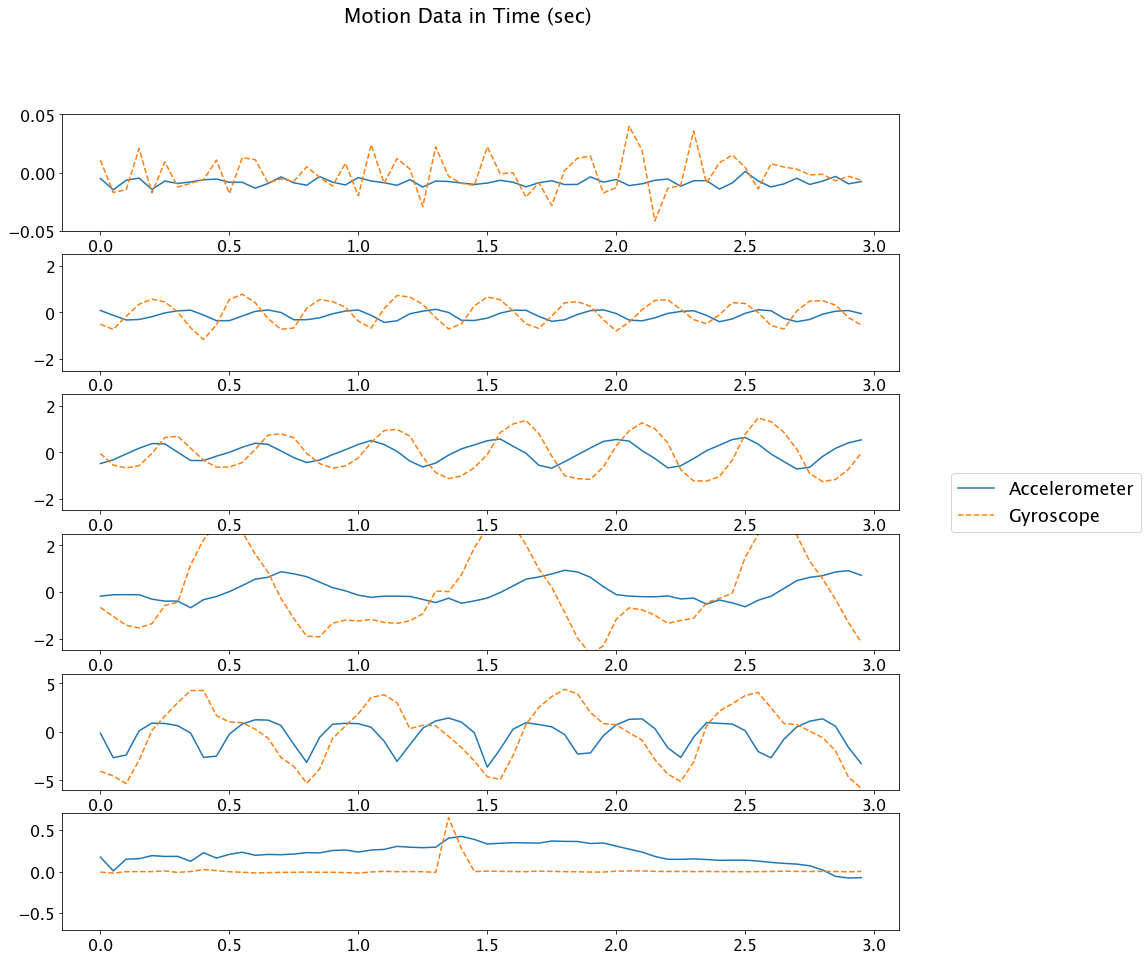

In [118]:
fig, axes = plt.subplots(6,1)
fig.set_size_inches(15,15)
fig.suptitle('Motion Data in Time (sec)')
random.seed(12345)
random_rows = []
for motion_label in ['0', '1', '2', '3', '4', '5']:
    random_rows.append(random.randint(len(AccelMax_in_time[AccelMax_in_time['Motion_Label']==motion_label])))
for motion_label, ax, ymax, random_row in zip(
    ['0', '1', '2', '3', '4', '5'], axes, [0.05, 2.5, 2.5, 2.5, 6, 0.7], random_rows):
    ax.plot(np.arange(0, SAMPLES_FFT)*SAMPLING_INTERVAL, AccelMax_in_time[AccelMax_in_time['Motion_Label']==motion_label].iloc[random_row, :-1].values)
    ax.plot(np.arange(0, SAMPLES_FFT)*SAMPLING_INTERVAL, GyroMax_in_time[GyroMax_in_time['Motion_Label']==motion_label].iloc[random_row, :-1].values, linestyle='--')
    ax.set(ylim=[-ymax, ymax])
plt.legend(['Accelerometer', 'Gyroscope'], bbox_to_anchor=(1.3, 4))
fig.savefig('figures/motion_sample.png', bbox_inches='tight')

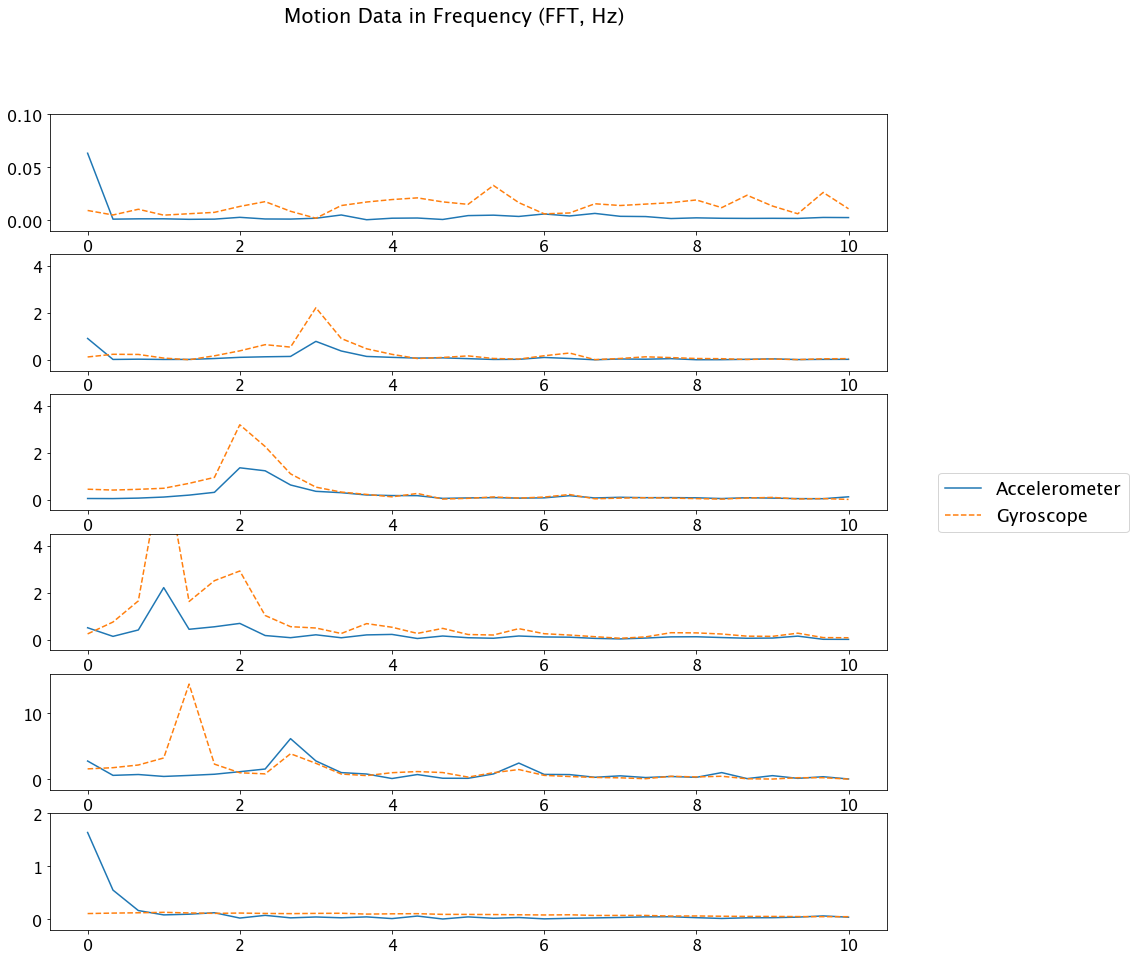

In [120]:
fig, axes = plt.subplots(6,1)
fig.set_size_inches(15,15)
fig.suptitle('Motion Data in Frequency (FFT, Hz)')
for motion_label, ax, ymax, random_row in zip(
    ['0', '1', '2', '3', '4', '5'], axes, [0.1, 4.5, 4.5, 4.5, 16, 2], random_rows):
    ax.plot(np.arange(0, num_fft)*SAMPLING_INTERVAL_FFT, AccelMax_in_freq[AccelMax_in_freq['Motion_Label']==motion_label].iloc[random_row, :-1].values)
    ax.plot(np.arange(0, num_fft)*SAMPLING_INTERVAL_FFT, GyroMax_in_freq[GyroMax_in_freq['Motion_Label']==motion_label].iloc[random_row, :-1].values, linestyle='--')
    ax.set(ylim=[-ymax*0.1, ymax])
plt.legend(['Accelerometer', 'Gyroscope'], bbox_to_anchor=(1.3, 4))
fig.savefig('figures/motion_sample_fft.png', bbox_inches='tight')

In [122]:
names = [j+i for i in ['Max_Amp', 'Mean_Amp', 'Std_Amp', 'Peak_Freq', 'Mean_Freq', 'Central_Power', 'Central_Power_Ratio'] for j in ['Accel_', 'Gyro_']] + ['Motion_Label']
#names = [j+i for i in ['Max_Amp', 'Mean_Amp', 'Std_Amp', 'Skew_Amp', 'Kurtosis_Amp', 'Peak_Freq', 'Mean_Freq', 'Central_Power', 'Central_Power_Ratio'] for j in ['Accel_', 'Gyro_']] + ['Motion_Label']

In [123]:
motion_data = pd.DataFrame(motion_data, columns=names)

In [125]:
min(motion_data[motion_data['Motion_Label'] == '1']['Accel_Max_Amp'])

0.07703844923726498

In [126]:
motion_data.loc[:, 'Tremor'] = motion_data['Motion_Label'].map({'0':'0', '1':'1', '2':'0', '3':'0', '4':'0', '5':'0'})

In [127]:
motion_data.groupby('Motion_Label').agg({'Motion_Label':'size'})

,Motion_Label
Motion_Label,
0,2195
1,2704
2,1734
3,732
4,946
5,978


In [128]:
motion_data.groupby('Tremor').agg({'Tremor':'size'})

,Tremor
Tremor,
0,6585
1,2704


In [130]:
# from imblearn.over_sampling import RandomOverSampler
# ros = RandomOverSampler(random_state=0)
# X_resampled, y_resampled = ros.fit_resample(motion_data.iloc[:,:-2], motion_data.iloc[:,-2])

# from collections import Counter
# print(sorted(Counter(y_resampled).items()))

In [131]:
data = motion_data.iloc[:, :-2]
labels = motion_data.iloc[:, -2]

In [132]:
#data_trainval, data_test, labels_trainval, labels_test = train_test_split(data, labels, test_size=0.20, shuffle=True, random_state=12345)
#data_train, data_val, labels_train, labels_val = train_test_split(data_trainval, labels_trainval, test_size=0.20, shuffle=True, random_state=54321)

data_train, data_val, labels_train, labels_val = train_test_split(data, labels, test_size=0.20, shuffle=True, stratify=labels, random_state=654321)

In [133]:
labels_train.value_counts()

1    2163
0    1756
2    1387
5     782
4     757
3     586
Name: Motion_Label, dtype: int64

In [134]:
labels_val.value_counts()

1    541
0    439
2    347
5    196
4    189
3    146
Name: Motion_Label, dtype: int64

In [135]:
import multiprocessing
multiprocessing.cpu_count()
num_features = len(data_train.columns) # get number of features in machine learning

## Machine Learning

In [136]:
def plot_importance(clf, columns):
    # plot feature importance
    plt.figure(figsize=(10, 6))
    feature_importance = clf.feature_importances_
    # make importances relative to max importance
    feature_importance = 100.0 * (feature_importance / feature_importance.max())
    sorted_idx = np.argsort(feature_importance)
    pos = np.arange(sorted_idx.shape[0]) + .5
    plt.barh(pos, feature_importance[sorted_idx], align='center')
    plt.yticks(pos, columns[sorted_idx])
    plt.xlabel('Relative Importance')
    plt.title('Feature Importance')

In [137]:
tmp_motion = [4.02080380624758,7.39824239818497,0.437064480554548,1.086708747075,0.722631743824806,1.40033027846747,
              3.33333333333333,3.33333333333333,3.74362377059133,4.34964879853189,1.31566497957239,5.73730185780765,
              1.88930002622942,1.86360432132204]
# tmp_motion = [4.02080380624758,7.39824239818497,0.437064480554548,1.086708747075,0.722631743824806,1.40033027846747, 1, 1, 1, 1,
#               3.33333333333333,3.33333333333333,3.74362377059133,4.34964879853189,1.31566497957239,5.73730185780765,
#               1.88930002622942,1.86360432132204]

### Random Forest

In [138]:
random.seed(10000)
rf_params = {
    'n_jobs': multiprocessing.cpu_count()-2,
    'criterion': 'gini',
    'n_estimators': 1000,
    'max_features': 0.7,
    'max_depth': 9,
    'min_samples_leaf': 5
}

clf_RF=RFC(**rf_params)
cv_RF = cross_validate(clf_RF, data_train, labels_train, cv=5)
clf_RF.fit(data_train, labels_train)
labels_val_pred = clf_RF.predict(data_val)
labels_val_pred = pd.Series(labels_val_pred, index=data_val.index, dtype='category')
cm = skl.metrics.confusion_matrix(labels_val, labels_val_pred)
cm
#cm/cm.sum(axis=1)*100

array([[439,   0,   0,   0,   0,   0],
       [  1, 516,  24,   0,   0,   0],
       [  0,  28, 316,   2,   0,   1],
       [  0,   3,   0, 143,   0,   0],
       [  0,   0,   1,   0, 188,   0],
       [  2,   0,   0,   0,   0, 194]])

In [139]:
score_RF_cv = cv_RF['test_score'].mean()
score_RF_cv

0.9609744750602122

In [140]:
score_RF = clf_RF.score(data_val,labels_val) # = cm.trace()/cm.sum() 
# accuracy_score(labels_val, clf_RF.predict(data_val))
# np.sum(np.array(labels_val)==clf_RF.predict(data_val))/labels_val.size
score_RF

0.9666307857911733

In [141]:
sum(clf_RF.predict_proba(data_val).max(axis=1)<0.7)

76

In [142]:
clf_RF.predict(np.array(tmp_motion).reshape(1,-1))

array(['1'], dtype=object)

In [143]:
clf_RF.predict_proba(np.array(tmp_motion).reshape(1,-1))

array([[2.63157895e-05, 9.63529167e-01, 3.60209760e-02, 4.23541425e-04,
        0.00000000e+00, 0.00000000e+00]])

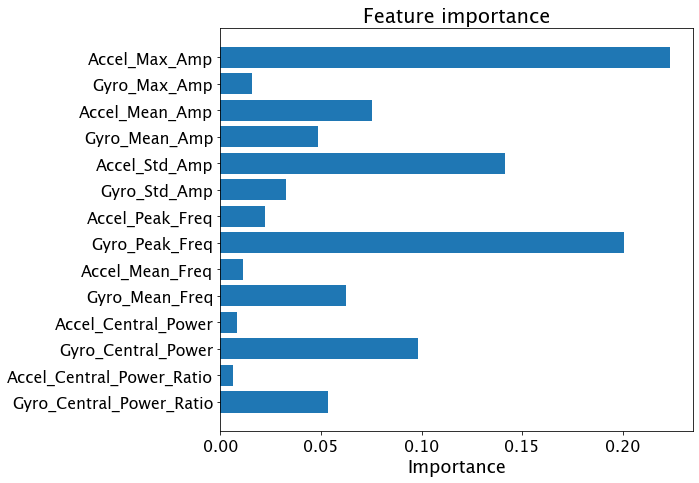

In [144]:
importance = clf_RF.feature_importances_
importance = pd.DataFrame(importance, index=data_train.columns, 
                          columns=["Importance"])
importance["Std"] = np.std([tree.feature_importances_
                            for tree in clf_RF.estimators_], axis=0)

#x = range(importance.shape[0])
x = data_train.columns
y = importance.iloc[:, 0]
yerr = importance.iloc[:, 1]
plt.figure(figsize=(10,7))
plt.barh(x, y, align="center")
plt.gca().invert_yaxis()
plt.title('Feature importance')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

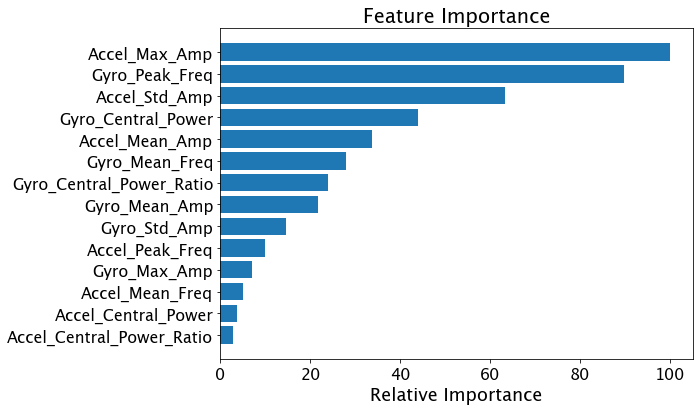

In [145]:
plot_importance(clf_RF, data_train.columns)
plt.tight_layout()
plt.savefig('figures/Feature_Importance_RF.png');

### Decision Tree

In [37]:
random.seed(10000)
dt_params = {
    'criterion': 'gini',
    'splitter': 'best',
    'max_depth': 9,
    'min_samples_leaf': 5
}

clf_DT=DecisionTreeClassifier(**dt_params)
cv_DT = cross_validate(clf_DT, data_train, labels_train, cv=5)
clf_DT.fit(data_train, labels_train)

labels_val_pred = clf_DT.predict(data_val)
labels_val_pred = pd.Series(labels_val_pred, index=data_val.index, dtype='category')
cm = skl.metrics.confusion_matrix(labels_val, labels_val_pred)
cm

array([[439,   0,   0,   0,   0,   0],
       [  1, 513,  27,   0,   0,   0],
       [  0,  43, 301,   1,   1,   1],
       [  0,   0,   1, 106,   0,   0],
       [  0,   0,   1,   0, 188,   0],
       [  2,   0,   2,   0,   0, 192]])

In [38]:
score_DT_cv = cv_DT['test_score'].mean()
score_DT_cv

0.9511875715734222

In [39]:
score_DT = clf_DT.score(data_val,labels_val) # = cm.trace()/cm.sum() 
score_DT

0.9560197910940077

### Extreme Gradient Boosting

In [42]:
random.seed(10000)
xgb_params = {
    'booster': 'gbtree',
    'max_depth': 9,
    'min_child_weight': 1,
    'learning_rate': 0.01,
    'n_estimators': 1000,
    'n_jobs': multiprocessing.cpu_count()-2,
    #'silent': True,
    'objective': 'multi:softmax',
    #'gamma': 0,
    #'min_child_weight': 5,
    #'max_delta_step': 0,
    'subsample': 0.7,
    'colsample_bytree': 0.7,
    'colsample_bylevel': 0.7,
    #'reg_alpha': 0,
    #'reg_lambda': 0,
    #'scale_pos_weight': 1,
    #'missing': None,
    'seed': 10000
}
clf_XGB=XGB.XGBClassifier(**xgb_params)
cv_XGB = cross_validate(clf_XGB, data_train, labels_train, cv=5)
clf_XGB.fit(data_train, labels_train)

labels_val_pred = clf_XGB.predict(data_val)
labels_val_pred = pd.Series(labels_val_pred, index=data_val.index, dtype='category')
cm = skl.metrics.confusion_matrix(labels_val, labels_val_pred)
cm

array([[439,   0,   0,   0,   0,   0],
       [  1, 523,  17,   0,   0,   0],
       [  0,  33, 314,   0,   0,   0],
       [  0,   0,   0, 107,   0,   0],
       [  0,   0,   0,   0, 189,   0],
       [  1,   0,   1,   0,   0, 194]])

In [43]:
score_XGB_cv = cv_XGB['test_score'].mean()
score_XGB_cv

0.968239577493185

In [44]:
score_XGB = clf_XGB.score(data_val,labels_val) # = cm.trace()/cm.sum() 
score_XGB

0.9708631115997801

In [45]:
sum(clf_XGB.predict_proba(data_val).max(axis=1)<0.7)

33

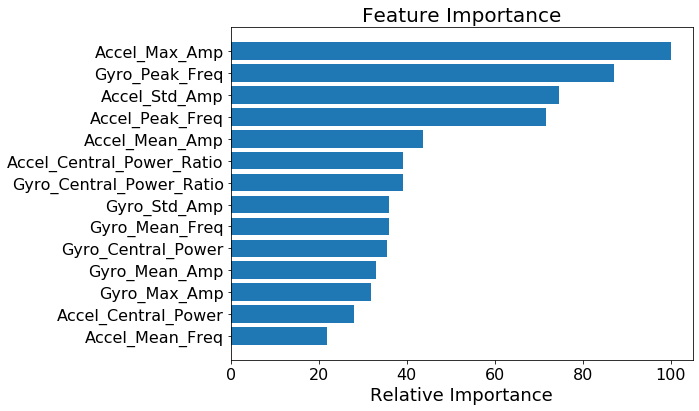

In [46]:
plot_importance(clf_XGB, data_train.columns)
plt.tight_layout()

In [47]:
# XGB.plot_importance(clf_XGB);
# plt.show()

In [48]:
# xgb_train = XGB.DMatrix(data_train, label = np.array(labels_train))
# xgb_val = XGB.DMatrix(data_val, label = np.array(labels_val))
# watch_list = [(xgb_train, 'train'),(xgb_val, 'val')]
# clf_XGB = XGB.train({
#     #'booster': 'gbtree',
#     'max_depth': round(num_features*0.5),
#     #'min_child_weight': 1,
#     'learning_rate': 0.01,
#     #'n_estimators': 1000,
#     #'n_jobs': multiprocessing.cpu_count()-2,
#     #'silent': True,
#     #'objective': 'multi:softmax',
#     #'gamma': 0,
#     #'min_child_weight': 5,
#     #'max_delta_step': 0,
#     #'subsample': 0.7,
#     #'colsample_bytree': 0.7,
#     #'colsample_bylevel': 0.7,
#     #'reg_alpha': 0,
#     #'reg_lambda': 0,
#     #'scale_pos_weight': 1,
#     #'missing': None,
#     'seed': 10000
# }, xgb_train, num_boost_round=2000, evals=watch_list, early_stopping_rounds=1000)

# clf_XGB.predict(XGB.DMatrix(data_val))

### AdaBoosting Machine

In [49]:
random.seed(10000)
adaboost_params = {
    'base_estimator': RFC(n_estimators=1000,n_jobs=-1,max_features=9),
    'n_estimators': 500, 
    'learning_rate': 0.01, 
    #'max_depth': 9, 
    #'max_features': 0.7,
    #'subsample': 0.7,
    #'min_samples_leaf': 5, 
    #'min_samples_split': 15
}

clf_AdaBoost=AdaBoost(**adaboost_params)
cv_AdaBoost = cross_validate(clf_AdaBoost, data_train, labels_train, cv=5)
clf_AdaBoost.fit(data_train, labels_train)

labels_val_pred = clf_AdaBoost.predict(data_val)
labels_val_pred = pd.Series(labels_val_pred, index=data_val.index, dtype='category')
cm = skl.metrics.confusion_matrix(labels_val, labels_val_pred)
cm

array([[439,   0,   0,   0,   0,   0],
       [  1, 518,  22,   0,   0,   0],
       [  0,  32, 314,   0,   0,   1],
       [  0,   0,   0, 107,   0,   0],
       [  0,   0,   1,   0, 188,   0],
       [  2,   0,   1,   0,   0, 193]])

In [50]:
score_AdaBoost_cv = cv_AdaBoost['test_score'].mean()
score_AdaBoost_cv

0.9654895783591961

In [51]:
score_AdaBoost = clf_AdaBoost.score(data_val,labels_val) # = cm.trace()/cm.sum() 
score_AdaBoost

0.9670148433205058

In [52]:
sum(clf_AdaBoost.predict_proba(data_val).max(axis=1)<0.7)

66

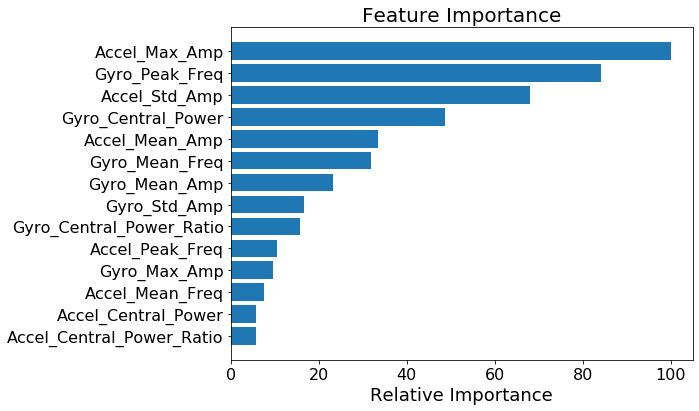

In [53]:
plot_importance(clf_AdaBoost, data_train.columns)
plt.tight_layout()

### Gradient Boosting Machine

In [54]:
random.seed(10000)
gbm_params = {
    'n_estimators': 1000, 
    'learning_rate': 0.01, 
    'max_depth': 9, 
    'max_features': 0.7,
    'subsample': 0.7,
    'min_samples_leaf': 5, 
    'min_samples_split': 15
}

clf_GBM=GBC(**gbm_params)
cv_GBM = cross_validate(clf_GBM, data_train, labels_train, cv=5)
clf_GBM.fit(data_train, labels_train)

labels_val_pred = clf_GBM.predict(data_val)
labels_val_pred = pd.Series(labels_val_pred, index=data_val.index, dtype='category')
cm = skl.metrics.confusion_matrix(labels_val, labels_val_pred)
cm

array([[439,   0,   0,   0,   0,   0],
       [  1, 519,  21,   0,   0,   0],
       [  0,  30, 317,   0,   0,   0],
       [  0,   0,   0, 107,   0,   0],
       [  0,   0,   0,   0, 189,   0],
       [  1,   0,   1,   0,   0, 194]])

In [55]:
score_GBM_cv = cv_GBM['test_score'].mean()
score_GBM_cv

0.9674154958163366

In [56]:
score_GBM = clf_GBM.score(data_val,labels_val) # = cm.trace()/cm.sum() 
score_GBM

0.9703133589884552

In [57]:
sum(clf_GBM.predict_proba(data_val).max(axis=1)<0.7)

27

In [58]:
def plot_importance_GBM(clf, X_test, y_test, params):
    # Plot training deviance
    # compute test set deviance
    test_score = np.zeros((params['n_estimators'],), dtype=np.float64)

    for i, y_pred in enumerate(clf.staged_predict_proba(X_test)):
        test_score[i] = clf.loss_(y_test, y_pred) #np.sum(np.array(y_test)==y_pred)

    plt.figure(figsize=(18, 6))
    plt.subplot(1, 2, 1)
    plt.title('Deviance')
    plt.plot(np.arange(params['n_estimators']) + 1, clf.train_score_, 'b-',
             label='Training Deviance')
    plt.plot(np.arange(params['n_estimators']) + 1, test_score, 'r-',
             label='Testing Deviance')
    plt.legend(loc='upper right')
    plt.xlabel('Boosting Iterations')
    plt.ylabel('Deviance (Loss)')

    # Plot feature importance
    feature_importance = clf.feature_importances_
    # make importances relative to max importance
    feature_importance = 100.0 * (feature_importance / feature_importance.max())
    sorted_idx = np.argsort(feature_importance)
    pos = np.arange(sorted_idx.shape[0]) + .5
    plt.subplot(1, 2, 2)
    plt.barh(pos, feature_importance[sorted_idx], align='center')
    plt.yticks(pos, X_test.columns[sorted_idx])
    plt.xlabel('Relative Importance')
    plt.title('Feature Importance')
    plt.show()

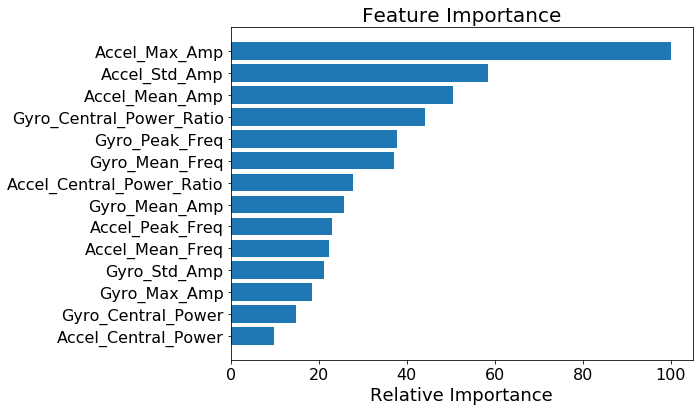

In [59]:
#plot_importance_GBM(clf_GBM, data_val, labels_val, gbm_params)
plot_importance(clf_GBM, data_train.columns)
plt.tight_layout()

In [60]:
# parameters = {'max_depth':[9, 12], 'max_features':[0.7, 0.9], 'subsample':[0.7, 0.9]}

# gbm_params = {
#     'n_estimators': 1000, 
#     'learning_rate': 0.01, 
#     'min_samples_leaf': 5, 
#     'min_samples_split': 5
# }
# clf_GBM=GBC(**gbm_params)
# gs_GBM = GridSearchCV(clf_GBM, parameters, cv=3, n_jobs = multiprocessing.cpu_count()-2)
# gs_result = gs_GBM.fit(data_train, labels_train)

# print("Best: %f using %s" % (gs_result.best_score_, gs_result.best_params_))
# means = gs_result.cv_results_['mean_test_score']
# stds = gs_result.cv_results_['std_test_score']
# params = gs_result.cv_results_['params']
# for mean, stdev, param in zip(means, stds, params):
#     print("%f (%f) with: %r" % (mean, stdev, param))

### Support Vector Machine

In [61]:
random.seed(10000)
svm_params = {
    'C':1, 
    'kernel': 'rbf',
    'gamma': 'auto',
    'max_iter': -1,
    'probability': True 
}

clf_SVM=SVC(**svm_params)
cv_SVM = cross_validate(clf_SVM, data_train, labels_train, cv=5)
clf_SVM.fit(data_train, labels_train)

labels_val_pred = clf_SVM.predict(data_val)
labels_val_pred = pd.Series(labels_val_pred, index=data_val.index, dtype='category')
cm = skl.metrics.confusion_matrix(labels_val, labels_val_pred)
cm

array([[433,   0,   0,   0,   0,   6],
       [  3, 514,  24,   0,   0,   0],
       [  0,  32, 308,   6,   1,   0],
       [  0,   0,   0, 107,   0,   0],
       [  0,   0,   0,   0, 189,   0],
       [ 55,   0,   1,   0,   0, 140]])

In [62]:
score_SVM_cv = cv_SVM['test_score'].mean()
score_SVM_cv

0.9242341070194071

In [63]:
score_SVM = clf_SVM.score(data_val,labels_val) # = cm.trace()/cm.sum() 
score_SVM

0.9296316657504123

In [64]:
sum(clf_SVM.predict_proba(data_val).max(axis=1)<0.7)

95

### Deep Learning

In [65]:
#from keras.utils import to_categorical
from keras.models import Sequential
from keras.layers import Dense, Activation, LeakyReLU, ReLU, Dropout, BatchNormalization
from keras.optimizers import RMSprop, Adam
from keras.wrappers.scikit_learn import KerasClassifier
from keras import regularizers
from keras import callbacks

Using TensorFlow backend.


In [139]:
#random.RandomState(12345)
random.seed(12345)
set_random_seed(12345)
np.random.seed(12345)

In [140]:
# label_encoder = LabelEncoder()
# onehot_encoder = OneHotEncoder(sparse=False)

# integer_encoded = label_encoder.fit_transform(labels_train)
# integer_encoded = integer_encoded.reshape(len(integer_encoded), 1)
# labels_train_onehot = onehot_encoder.fit_transform(integer_encoded)

# integer_encoded = label_encoder.transform(labels_val)
# integer_encoded = integer_encoded.reshape(len(integer_encoded), 1)
# labels_val_onehot = onehot_encoder.transform(integer_encoded)

In [1]:
onehot_encoder = OneHotEncoder(sparse=False)
labels_train_onehot = onehot_encoder.fit_transform(pd.DataFrame(labels_train))
labels_val_onehot = onehot_encoder.transform(pd.DataFrame(labels_val))
#labels_train_onehot = onehot_encoder.fit_transform(np.array(labels_train).reshape(-1,1))
#labels_train_onehot = to_categorical(labels_train)

# invert
# label_encoder.inverse_transform(np.argmax(labels_train_onehot, axis=1))

In [150]:
# # scaler = MinMaxScaler()
scaler = StandardScaler()
# data_train = scaler.fit_transform(data_train)
# data_val = scaler.transform(data_val)

In [158]:
# glorot_uniform & glorot_normal
model = Sequential()
model.add(Dense(12, input_dim=num_features, kernel_initializer='glorot_uniform', activation='relu'))
model.add(BatchNormalization())
model.add(Dense(8, kernel_initializer='glorot_uniform', activation='relu'))
model.add(BatchNormalization())
model.add(Dense(6, kernel_initializer='glorot_uniform', activation='softmax'))
# Compile model
model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

In [159]:
# model = Sequential()
# model.add(Dense(12, input_dim=num_features, kernel_initializer='normal', kernel_regularizer=regularizers.l2(0.00), activation=None))
# model.add(BatchNormalization())
# #model.add(LeakyReLU(alpha=0.05))
# model.add(ReLU())
# #model.add(Dropout(0.1))
# model.add(Dense(8, kernel_initializer='normal', kernel_regularizer=regularizers.l2(0.00), activation=None))
# model.add(BatchNormalization())
# #model.add(LeakyReLU(alpha=0.05))
# model.add(ReLU())
# #model.add(Dropout(0.1))
# model.add(Dense(6, kernel_initializer='normal', kernel_regularizer=regularizers.l2(0.00), activation='softmax'))
# # Compile model
# #rmsprop = RMSprop(lr=0.001, rho=0.9, epsilon=1e-08, decay=0.0)
# adam = Adam(lr=0.001, beta_1=0.9, beta_2=0.999, epsilon=None, decay=0.0, amsgrad=False)
# model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

In [1]:
epochs = 300
es = callbacks.EarlyStopping(monitor='val_loss', min_delta=0.001, patience=round(epochs*0.1), verbose=1, mode='min')
history = model.fit(data_train.values, labels_train_onehot, validation_split=0.20, epochs=epochs, batch_size=200) #callbacks=[es])

In [161]:
#model.predict(data_val.values)

In [162]:
model.summary()

_________________________________________________________________
Layer (type)                 Output Shape              Param #   
dense_31 (Dense)             (None, 12)                180       
_________________________________________________________________
batch_normalization_21 (Batc (None, 12)                48        
_________________________________________________________________
dense_32 (Dense)             (None, 8)                 104       
_________________________________________________________________
batch_normalization_22 (Batc (None, 8)                 32        
_________________________________________________________________
dense_33 (Dense)             (None, 6)                 54        
Total params: 418
Trainable params: 378
Non-trainable params: 40
_________________________________________________________________


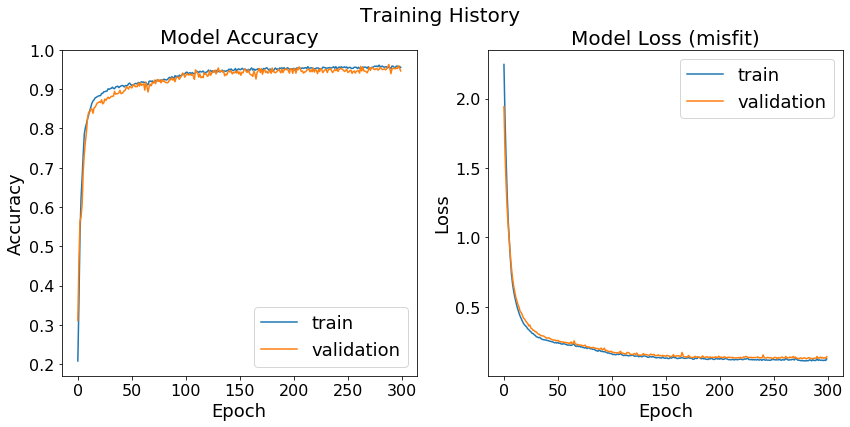

In [167]:
fig, [ax1, ax2] = plt.subplots(1,2)
fig.suptitle('Training History')
fig.set_size_inches(14,6)

ax1.plot(history.history['acc'])
ax1.plot(history.history['val_acc'])
ax1.set_title('Model Accuracy')
ax1.set_ylabel('Accuracy')
ax1.set_xlabel('Epoch')
ax1.legend(['train', 'validation'], loc='best')

ax2.plot(history.history['loss'])
ax2.plot(history.history['val_loss'])
ax2.set_title('Model Loss (misfit)')
ax2.set(xlabel='Epoch', ylabel='Loss')
ax2.legend(['train', 'validation'], loc='best')
plt.savefig('figures/Accuracy_CV.png');

In [164]:
model_loss, model_score = model.evaluate(data_val.values, labels_val_onehot)
model_score

1819/1819 [==============================] - 0s 22us/step


0.9543705335877111

In [77]:
model.predict(np.array(tmp_motion).reshape(1,-1))

array([[1.9221851e-07, 9.8940301e-01, 2.5006244e-03, 1.9987314e-09,
        8.0918726e-03, 4.1944704e-06]], dtype=float32)

In [78]:
sum(model.predict_proba(data_val.values).max(axis=1)<0.7)

101

In [82]:
def create_model(optimizer='rmsprop', init='glorot_uniform'):
    # create model
    model = Sequential()
    model.add(Dense(12, input_dim=num_features, kernel_initializer=init, activation='relu'))
    model.add(BatchNormalization())
    model.add(Dense(8, kernel_initializer=init, activation='relu'))
    model.add(BatchNormalization())
    model.add(Dense(6, kernel_initializer=init, activation='softmax'))
    # Compile model
    model.compile(loss='categorical_crossentropy', optimizer=optimizer, metrics=['accuracy'])
    return model

optimizers = ['adam'] # ['rmsprop', 'adam']
init = ['glorot_uniform'] # ['glorot_uniform', 'normal', 'uniform']
batch_size = [200, 128]
param_grid = dict(optimizer=optimizers, init=init, batch_size=batch_size)
model_gs = KerasClassifier(build_fn=create_model, epochs=300, verbose=0)
gs = GridSearchCV(estimator=model_gs, param_grid=param_grid, cv=5, n_jobs = multiprocessing.cpu_count()-2, verbose=0)
gs_result = gs.fit(data_train, labels_train_onehot)

In [81]:
print("Best: %f using %s" % (gs_result.best_score_, gs_result.best_params_))
means = gs_result.cv_results_['mean_test_score']
stds = gs_result.cv_results_['std_test_score']
params = gs_result.cv_results_['params']
for mean, stdev, param in zip(means, stds, params):
    print("%f (%f) with: %r" % (mean, stdev, param))

Best: 0.956139 using {'batch_size': 200, 'init': 'glorot_uniform', 'optimizer': 'adam'}
0.956139 (0.004066) with: {'batch_size': 200, 'init': 'glorot_uniform', 'optimizer': 'adam'}
0.955177 (0.004827) with: {'batch_size': 128, 'init': 'glorot_uniform', 'optimizer': 'adam'}


In [ ]:
def create_model(optimizer='adam', init='glorot_uniform'):
    # create model
    model = Sequential()
    model.add(Dense(12, input_dim=num_features, kernel_initializer=init, activation='relu'))
    model.add(BatchNormalization())
    model.add(Dense(8, kernel_initializer=init, activation='relu'))
    model.add(BatchNormalization())
    model.add(Dense(6, kernel_initializer=init, activation='softmax'))
    # Compile model
    model.compile(loss='categorical_crossentropy', optimizer=optimizer, metrics=['accuracy'])
    return model

fit_params = dict(batch_size=128, epochs=200)
model_wrap = KerasClassifier(build_fn=create_model, **fit_params, verbose=0)
model_pipeline = Pipeline([('scaler', scaler), ('clf', model_wrap)])
model_pipeline.fit(data_train, labels_train_onehot)

In [ ]:
model_pipeline.predict(data_val.values)

In [ ]:
model_pipeline.score(data_val.values, labels_val_onehot)

### Machine Learning Summary

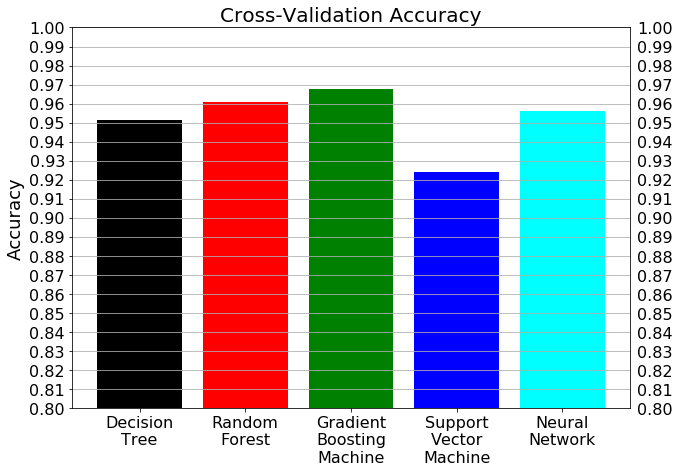

In [94]:
height = [score_DT_cv, score_RF_cv, score_GBM_cv, score_SVM_cv, gs_result.best_score_]
bars = ('Decision\nTree', 'Random\nForest', 'Gradient\nBoosting\nMachine', 'Support\nVector\nMachine', 'Neural\nNetwork')
y_pos = np.arange(len(bars))
plt.figure(figsize=(10, 7))
plt.grid(axis='y')
plt.bar(y_pos, height, color=('black', 'red', 'green', 'blue', 'cyan'))
plt.xticks(y_pos, bars)
plt.tick_params(labelright=True)
plt.ylim(0.8, 1)
plt.yticks(np.linspace(0.8, 1, 21))
plt.ylabel('Accuracy')
plt.title('Cross-Validation Accuracy')
plt.savefig('figures/Accuracy_CV.png');


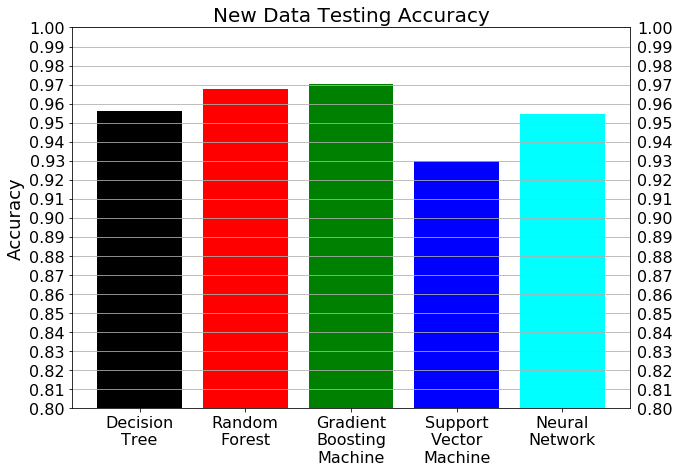

In [166]:
height = [score_DT, score_RF, score_GBM, score_SVM, model_score]
bars = ('Decision\nTree', 'Random\nForest', 'Gradient\nBoosting\nMachine', 'Support\nVector\nMachine', 'Neural\nNetwork')
y_pos = np.arange(len(bars))
plt.figure(figsize=(10, 7))
plt.grid(axis='y')
plt.bar(y_pos, height, color=('black', 'red', 'green', 'blue', 'cyan'))
plt.xticks(y_pos, bars)
plt.tick_params(labelright=True)
plt.ylim(0.8, 1)
plt.yticks(np.linspace(0.8, 1, 21))
plt.ylabel('Accuracy')
plt.title('New Data Testing Accuracy')
plt.savefig('figures/Accuracy.png');


In [ ]:
stop

## Output to CoreML model

In [ ]:
import coremltools
import tfcoreml

### RF CoreML model

In [ ]:
coreml_model = coremltools.converters.sklearn.convert(clf_RF, input_features="input_RF_model")
coreml_model.short_description = "Parkinson's Tremor Detection (based on Random Forest model)"
coreml_model.input_description['input_RF_model'] = 'Input data from accelerometer and gyroscope sensors'
coreml_model.output_description['classLabel'] = 'The most likely class label, for a given input.'
coreml_model.output_description['classProbability'] = 'The probabilities for each class label, for a given input.'
coreml_model.save('TremorDetection_RF.mlmodel')

clf_RF_load =  coremltools.models.MLModel('TremorDetection.mlmodel')
clf_RF_load.predict

### SVM CoreML model

In [ ]:
# coreml_model = coremltools.converters.sklearn.convert(clf_SVM)
# coreml_model.short_description = "Parkinson's Tremor Detection"
# coreml_model.input_description['input'] = 'Input data from accelerometer and gyroscope sensors'
# coreml_model.output_description['classLabel'] = 'The most likely class label, for a given input.'
# coreml_model.output_description['classProbability'] = 'The probabilities for each class label, for a given input.'
# coreml_model.save('TremorDetection_SVM.mlmodel')

# clf_SVM_load = coremltools.models.MLModel('TremorDetection_SVM.mlmodel')
# clf_SVM_load.predict

### XGB CoreML model

In [ ]:
# coreml_model = coremltools.converters.xgboost.convert(clf_XGB)
# coreml_model.short_description = "Parkinson's Tremor Detection"
# #coreml_model.input_description['input'] = 'Input data from accelerometer and gyroscope sensors'
# #coreml_model.output_description['classLabel'] = 'The most likely class label, for a given input.'
# #coreml_model.output_description['classProbability'] = 'The probabilities for each class label, for a given input.'
# coreml_model.save('TremorDetection_XGB.mlmodel')

# clf_XGB_load =  coremltools.models.MLModel('TremorDetection_XGB.mlmodel')
# clf_XGB_load.predict

### NN CoreML model

In [ ]:
coreml_model = coremltools.converters.keras.convert(model, class_labels=['0', '1', '2', '3', '4', '5'],
                                                    input_names="input_NN_model")
#coreml_model = coremltools.converters.keras.convert(model)
coreml_model.short_description = "Parkinson's Tremor Detection (based on Neural Network model)"
coreml_model.input_description['input_NN_model'] = 'Input data from accelerometer and gyroscope sensors'
coreml_model.output_description['classLabel'] = 'The most likely class label, for a given input.'
#coreml_model.output_description['classProbability'] = 'The probabilities for each class label, for a given input.'
coreml_model.save('TremorDetection_NN.mlmodel')

model_load = coremltools.models.MLModel('TremorDetection_NN.mlmodel')
model_load.predict

### NN Pipeline CoreML model

In [ ]:
# model_pipeline

In [ ]:
# coreml_model = coremltools.converters.sklearn.convert(model_pipeline, input_features="input_NN_model")
# coreml_model.short_description = "Parkinson's Tremor Detection (based on Neural Network model)"
# coreml_model.input_description['input_NN_model'] = 'Input data from accelerometer and gyroscope sensors'
# coreml_model.output_description['classLabel'] = 'The most likely class label, for a given input.'
# coreml_model.output_description['classProbability'] = 'The probabilities for each class label, for a given input.'
# coreml_model.save('TremorDetection_NN_Pipeline.mlmodel')

# model_load = coremltools.models.MLModel('TremorDetection_NN_Pipeline.mlmodel')
# model_load.predict

In [ ]:
# from keras import backend as K
# import tensorflow as tf
# def freeze_session(session, keep_var_names=None, output_names=None, clear_devices=True):
#     """
#     Freezes the state of a session into a pruned computation graph.

#     Creates a new computation graph where variable nodes are replaced by
#     constants taking their current value in the session. The new graph will be
#     pruned so subgraphs that are not necessary to compute the requested
#     outputs are removed.
#     @param session The TensorFlow session to be frozen.
#     @param keep_var_names A list of variable names that should not be frozen,
#                           or None to freeze all the variables in the graph.
#     @param output_names Names of the relevant graph outputs.
#     @param clear_devices Remove the device directives from the graph for better portability.
#     @return The frozen graph definition.
#     """
#     graph = session.graph
#     with graph.as_default():
#         freeze_var_names = list(set(v.op.name for v in tf.global_variables()).difference(keep_var_names or []))
#         output_names = output_names or []
#         output_names += [v.op.name for v in tf.global_variables()]
#         input_graph_def = graph.as_graph_def()
#         if clear_devices:
#             for node in input_graph_def.node:
#                 node.device = ""
#         frozen_graph = tf.graph_util.convert_variables_to_constants(
#             session, input_graph_def, output_names, freeze_var_names)
#         return frozen_graph
# # Create, compile and train model...
# frozen_graph = freeze_session(K.get_session(),
#                               output_names=[out.op.name for out in model.outputs])
# tf.train.write_graph(frozen_graph, "some_directory", "my_model.pb", as_text=False)
# tfcoreml.convert(tf_model_path = 'some_directory/my_model.pb',
#                  mlmodel_path = 'TremorDetection.mlmodel',
#                  output_feature_names = ['softmax'],
#                  #input_name_shape_dict = {'input' : [1, 227, 227, 3]},
#                  #use_coreml_3 = True
#                 )

## Dimensionality Reduction & Unsupervised Learning

In [ ]:
from sklearn.decomposition import PCA, TruncatedSVD, IncrementalPCA
from sklearn.manifold import TSNE
from sklearn.cluster import AgglomerativeClustering, DBSCAN, KMeans, SpectralClustering
from sklearn.neural_network import BernoulliRBM as RBM
from keras.models import Model
from keras.layers import Dense, Input
import umap
import hdbscan

In [ ]:
from mpl_toolkits.mplot3d import Axes3D
def plot_motion(data, views):
    colors = ['black', 'red', 'blue', 'cyan', 'purple', 'green']
    labels = ['0', '1', '2', '3', '4', '5']
    label_names = ['Still, minor/no motion', "Parkinson's tremor", "Fake tremor", "Walking", "Running", "Driving"]
    fig = plt.figure()
    fig.set_size_inches(20,10)
    #ax = Axes3D(fig)
    for i, view in enumerate(views):
        ax = fig.add_subplot(1, 3, i+1, projection='3d')
        ax.view_init(**view)
        for label, label_name, color in zip(labels, label_names, colors):
            ax.scatter(data[data['Label']==label]['X1'].tolist(),
                        data[data['Label']==label]['X2'].tolist(),
                        data[data['Label']==label]['X3'].tolist(),
                        color = color, label = label_name)
    #plt.legend(loc='best', bbox_to_anchor=(1.5, 0));

In [ ]:
import plotly.plotly as ply
import plotly.graph_objs as go
import plotly.offline
#plotly.tools.set_credentials_file(username='rexwang', api_key='I6gQ23Kl3BNYFY6g5jkH')
plotly.tools.set_credentials_file(username='', api_key='')
plotly.offline.init_notebook_mode()

In [ ]:
def plotly_motion(data):
    colors = ['black', 'red', 'blue', 'cyan', 'purple', 'green']
    labels = ['0', '1', '2', '3', '4', '5']
    label_names = ['Still, minor/no motion', "Parkinson's tremor", "Fake tremor", "Walking", "Running", "Driving"]
    scatters = []
    for label, label_name, color in zip(labels, label_names, colors):
        
        scatter = go.Scatter3d(
                            x=data[data['Label']==label]['X1'],
                            y=data[data['Label']==label]['X2'],
                            z=data[data['Label']==label]['X3'],
                            name=label_name,
                            mode='markers',
                            marker=dict(
                                size=5,
                                color=color,
                                opacity=1
                            )
                        )
        layout = go.Layout(
                margin=dict(
                    l=0,
                    r=0,
                    b=0,
                    t=0
                ),
                font=dict(
                    size=num_features
                ),
                legend=dict(x=0.8, y=0.5, font=dict(size=16))
            )
        scatters.append(scatter)
    fig = go.Figure(data=scatters, layout=layout)
    #return ply.iplot(fig, filename='3d-scatter')
    plotly.offline.iplot(fig)

In [ ]:
def plotly_motion_cluster(data, colors):
    labels = data['Label'].unique()
    #label_names = ['Still, minor/no motion', "Parkinson's tremor", "Fake tremor", "Walking", "Running", "Driving"]
    scatters = []
    for label, color in zip(labels, colors):
        #color = "#"+''.join([random.choice(list('0123456789ABCDEF')) for j in range(6)])
        scatter = go.Scatter3d(
                            x=data[data['Label']==label]['X1'],
                            y=data[data['Label']==label]['X2'],
                            z=data[data['Label']==label]['X3'],
                            #name=label_name,
                            mode='markers',
                            marker=dict(
                                size=5,
                                color=color,
                                opacity=1
                            )
                        )
        layout = go.Layout(
                margin=dict(
                    l=0,
                    r=0,
                    b=0,
                    t=0
                ),
                font=dict(
                    size=num_features
                ),
                showlegend=False
                #legend=dict(x=0.8, y=0.5, font=dict(size=16))
            )
        scatters.append(scatter)
    fig = go.Figure(data=scatters, layout=layout)
    #return ply.iplot(fig, filename='3d-scatter')
    plotly.offline.iplot(fig)

In [ ]:
#scaler = MinMaxScaler()
scaler = StandardScaler()
data_train = scaler.fit_transform(data_train)
data_val = scaler.transform(data_val)

### Raw Data, plot with 3 most important features

In [ ]:
data_raw_labeled = pd.DataFrame(np.column_stack([data_train[:,[0,7,4]],labels_train]), columns=['X1', 'X2', 'X3', 'Label'])
plotly_motion(data_raw_labeled)

### Principal Component Analysis 

In [ ]:
random.seed(12345)
pca = PCA(n_components=3)
data_pca = pca.fit_transform(data_train)
data_pca_labeled = pd.DataFrame(np.column_stack([data_pca,labels_train]), columns=['X1', 'X2', 'X3', 'Label'])
#plot_motion(data_pca_labeled, views = [dict(azim=10, elev=90), dict(azim=70, elev=30), dict(azim=130, elev=30)])
#plt.legend(loc='best', bbox_to_anchor=(2, 1));
plotly_motion(data_pca_labeled)

In [ ]:
random.seed(12345)
ipca = IncrementalPCA(n_components=3, batch_size=32)
data_ipca = ipca.fit_transform(data_train)
data_ipca_labeled = pd.DataFrame(np.column_stack([data_ipca,labels_train]), columns=['X1', 'X2', 'X3', 'Label'])
#plot_motion(data_ipca_labeled, views = [dict(azim=10, elev=90), dict(azim=70, elev=30), dict(azim=130, elev=30)])
#plt.legend(loc='best', bbox_to_anchor=(2, 1));
plotly_motion(data_ipca_labeled)

In [ ]:
random.seed(12345)
tsvd = TruncatedSVD(n_components=3)
data_tsvd = tsvd.fit_transform(data_train)
data_tsvd_labeled = pd.DataFrame(np.column_stack([data_tsvd,labels_train]), columns=['X1', 'X2', 'X3', 'Label'])
#plot_motion(data_tsvd_labeled, views = [dict(azim=70, elev=30)])
#plt.legend(loc='best', bbox_to_anchor=(2, 1));
plotly_motion(data_tsvd_labeled)

### t-distributed Stochastic Neighbor Embedding

In [ ]:
random.seed(12345)
tsne = TSNE(n_components=3, perplexity=100, learning_rate=100, n_iter=500, n_iter_without_progress=500, verbose=1)
#tsne = TSNE(n_components=3)
data_tsne = tsne.fit_transform(data_train)

In [ ]:
data_tsne_labeled = pd.DataFrame(np.column_stack([data_tsne,labels_train]), columns=['X1', 'X2', 'X3', 'Label'])
#plot_motion(data_tsne_labeled, views = [dict(azim=10, elev=90), dict(azim=0, elev=10), dict(azim=130, elev=10)])
#plt.legend(loc='best', bbox_to_anchor=(2, 1));
plotly_motion(data_tsne_labeled)

In [ ]:
random.seed(12345)
tsne1 = TSNE(n_components=3, perplexity=200, learning_rate=200, n_iter=500, n_iter_without_progress=500, verbose=1)
#tsne = TSNE(n_components=3)
data_tsne1 = tsne1.fit_transform(data_train)

In [ ]:
data_tsne1_labeled = pd.DataFrame(np.column_stack([data_tsne1,labels_train]), columns=['X1', 'X2', 'X3', 'Label'])
#plot_motion(data_tsne1_labeled, views = [dict(azim=10, elev=90), dict(azim=0, elev=10), dict(azim=130, elev=10)])
#plt.legend(loc='best', bbox_to_anchor=(2, 1));
plotly_motion(data_tsne1_labeled)

### Restricted Boltzmann Machine

In [ ]:
random.seed(12345)
rbm = RBM(n_components=3, learning_rate=0.01, n_iter=1000, batch_size=32, verbose=True)
data_rbm = rbm.fit_transform(data_train)
data_rbm_labeled = pd.DataFrame(np.column_stack([data_rbm,labels_train]), columns=['X1', 'X2', 'X3', 'Label'])

In [ ]:
#plot_motion(data_rbm_labeled, views = [dict(azim=10, elev=90), dict(azim=0, elev=10), dict(azim=130, elev=10)])
#plt.legend(loc='best', bbox_to_anchor=(2, 1));
plotly_motion(data_rbm_labeled)

### Auto-encoder

In [ ]:
set_random_seed(12345)
random.seed(12345)
encoding_dim = 3
input_data = Input(shape=(num_features,))

# encoder layers
encoded = Dense(6, activation='tanh')(input_data)
#encoded = Dense(8, activation='relu')(encoded)
#encoded = Dense(6, activation='relu')(encoded)
encoder_output = Dense(encoding_dim)(encoded)

# decoder layers
decoded = Dense(6, activation='tanh')(encoder_output)
#decoded = Dense(8, activation='relu')(decoded)
#decoded = Dense(12, activation='relu')(decoded)
decoded = Dense(num_features, activation='tanh')(decoded)

# construct the autoencoder model
autoencoder = Model(inputs=input_data, outputs=decoded)

# construct the encoder model for plotting
encoder = Model(inputs=input_data, outputs=encoder_output)

# compile autoencoder
autoencoder.compile(optimizer='adam', loss='mse')

# training
autoencoder.fit(data_train, data_train, epochs=100, batch_size=32, shuffle=True)

In [ ]:
autoencoder.evaluate(data_train, data_train)

In [ ]:
data_encoded = encoder.predict(data_train)
data_encoded_labeled = pd.concat([pd.DataFrame(data_encoded, columns=['X1','X2','X3']), pd.Series(labels_train, name='Label')], axis=1)
#plot_motion(data_encoded_labeled, views = [dict(azim=10, elev=90), dict(azim=0, elev=10), dict(azim=130, elev=10)])
#plt.legend(loc='best', bbox_to_anchor=(2, 1));
plotly_motion(data_encoded_labeled)

In [ ]:
# random.seed(12345)
# pca1 = PCA(n_components=3)
# data_pca1 = pca1.fit_transform(data_encoded)
# data_pca1_labeled = pd.DataFrame(np.column_stack([data_pca1,labels_train]), columns=['X1', 'X2', 'X3', 'Label'])
# #plot_motion(data_pca1_labeled, views = [dict(azim=10, elev=90), dict(azim=0, elev=10), dict(azim=130, elev=10)])
# #plt.legend(loc='best', bbox_to_anchor=(2, 1));

### Umap

In [ ]:
# import numba
# @numba.njit()
# def red_channel_dist(a,b):
#     return np.abs(a[0] - b[0])

In [ ]:
random.seed(12345)
umap_model = umap.UMAP(
    n_neighbors=100,
    min_dist=0.5,
    n_components=3,
    metric='minkowski'
)
data_umap = umap_model.fit_transform(data_train)

In [ ]:
data_umap_labeled = pd.DataFrame(np.column_stack([data_umap,labels_train]), columns=['X1', 'X2', 'X3', 'Label'])
#plot_motion(data_umap_labeled, views = [dict(azim=10, elev=90), dict(azim=0, elev=10), dict(azim=130, elev=10)])
#plt.legend(loc='best', bbox_to_anchor=(2, 1));
plotly_motion_cluster(data_umap_labeled, colors=['black']*6)
plotly_motion(data_umap_labeled)

In [ ]:
random.seed(12345)
umap_model = umap.UMAP(
    n_neighbors=100,
    min_dist=0.5,
    n_components=3,
    metric='euclidean'
)
data_umap = umap_model.fit_transform(data_train)

In [ ]:
data_umap_labeled = pd.DataFrame(np.column_stack([data_umap,labels_train]), columns=['X1', 'X2', 'X3', 'Label'])
#plot_motion(data_umap_labeled, views = [dict(azim=10, elev=90), dict(azim=0, elev=10), dict(azim=130, elev=10)])
#plt.legend(loc='best', bbox_to_anchor=(2, 1));
plotly_motion(data_umap_labeled)

### Agglomerative Clustering

In [ ]:
random.seed(12345)
data_ac = data_tsne
ac = AgglomerativeClustering(n_clusters=6, linkage='ward').fit(data_tsne)

In [ ]:
pd.concat([pd.DataFrame(data_ac, columns=['X1','X2','X3']).reset_index(drop=True),
           pd.Series(ac.labels_.astype(str), name='Predicted Label').reset_index(drop=True),
           pd.Series(labels_train, name='Label').reset_index(drop=True)], axis=1)

In [ ]:
data_ac_labeled = pd.concat([pd.DataFrame(data_ac, columns=['X1','X2','X3']), pd.Series(ac.labels_.astype(str), name='Label')], axis=1)
#plot_motion(data_ac_labeled, views = [dict(azim=10, elev=90), dict(azim=0, elev=10), dict(azim=130, elev=10)])
#plt.legend(loc='best', bbox_to_anchor=(2, 1));
#plotly_motion_cluster(data_ac_labeled, colors=['red','blue','cyan','purple','blue','green','black','purple','blue','black','green','red'])
plotly_motion(data_ac_labeled)

### DBSCAN - Density-Based Spatial Clustering of Applications with Noise

In [ ]:
random.seed(12345)
data_db = data_umap
db = DBSCAN(eps=0.3, min_samples=10, algorithm='kd_tree').fit(data_umap)

In [ ]:
pd.concat([pd.DataFrame(data_db, columns=['X1','X2','X3']).reset_index(drop=True),
           pd.Series(db.labels_.astype(str), name='Predicted Label').reset_index(drop=True),
           pd.Series(labels_train, name='Label').reset_index(drop=True)], axis=1)

In [ ]:
data_db_labeled = pd.concat([pd.DataFrame(data_db, columns=['X1','X2','X3']), pd.Series(db.labels_.astype(str), name='Label')], axis=1)
plot_motion(data_db_labeled, views = [dict(azim=10, elev=90), dict(azim=0, elev=10), dict(azim=130, elev=10)])
#plt.legend(loc='best', bbox_to_anchor=(2, 1));
#plotly_motion(data_db_labeled)

### HDBSCAN - Hierarchical Density-Based Spatial Clustering of Applications with Noise

In [ ]:
random.seed(12345)
data_hdb = data_umap
hdb = hdbscan.HDBSCAN(alpha=1.0, min_samples=30, min_cluster_size=100).fit(data_umap)

In [ ]:
pd.concat([pd.DataFrame(data_hdb, columns=['X1','X2','X3']).reset_index(drop=True),
           pd.Series(hdb.labels_.astype(str), name='Predicted Label').reset_index(drop=True),
           pd.Series(labels_train, name='Label').reset_index(drop=True)], axis=1)

In [ ]:
data_hdb_labeled = pd.concat([pd.DataFrame(data_hdb, columns=['X1','X2','X3']), pd.Series(hdb.labels_.astype(str), name='Label')], axis=1)
#plot_motion(data_hdb_labeled, views = [dict(azim=10, elev=90), dict(azim=0, elev=10), dict(azim=130, elev=10)])
#plt.legend(loc='best', bbox_to_anchor=(2, 1));
plotly_motion(data_hdb_labeled)

### K-Means

In [ ]:
random.seed(12345)
data_km = data_umap
km = KMeans(n_clusters=6).fit(data_umap)

In [ ]:
pd.concat([pd.DataFrame(data_km, columns=['X1','X2','X3']).reset_index(drop=True),
           pd.Series(km.labels_.astype(str), name='Predicted Label').reset_index(drop=True),
           pd.Series(labels_train, name='Label').reset_index(drop=True)], axis=1)

In [ ]:
data_km_labeled = pd.concat([pd.DataFrame(data_km, columns=['X1','X2','X3']), pd.Series(km.labels_.astype(str), name='Label')], axis=1)
#plot_motion(data_km_labeled, views = [dict(azim=10, elev=90), dict(azim=0, elev=10), dict(azim=130, elev=10)])
#plt.legend(loc='best', bbox_to_anchor=(2, 1));
#plotly_motion_cluster(data_km_labeled, colors=['blue','blue','green','purple','red','black','purple','blue','green','green'])
plotly_motion(data_km_labeled)

### Spectral Clustering

In [ ]:
random.seed(12345)
data_sc = data_umap
sc = SpectralClustering(n_clusters=6, assign_labels="discretize").fit(data_sc)

In [ ]:
pd.concat([pd.DataFrame(data_sc, columns=['X1','X2','X3']).reset_index(drop=True),
           pd.Series(sc.labels_.astype(str), name='Predicted Label').reset_index(drop=True),
           pd.Series(labels_train, name='Label').reset_index(drop=True)], axis=1)

In [ ]:
data_sc_labeled = pd.concat([pd.DataFrame(data_sc, columns=['X1','X2','X3']), pd.Series(sc.labels_.astype(str), name='Label')], axis=1)
#plot_motion(data_sc_labeled, views = [dict(azim=10, elev=90), dict(azim=0, elev=10), dict(azim=130, elev=10)])
#plt.legend(loc='best', bbox_to_anchor=(2, 1));
#plotly_motion_cluster(data_sc_labeled, colors=['blue','blue','green','purple','red','black','purple','blue','green','green'])
plotly_motion(data_sc_labeled)